In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("Profit Analysis.csv")

In [19]:
# Data Check

In [21]:
df.info()
#df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RD_Spend         50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing_Spend  50 non-null     float64
 3   Profit           50 non-null     float64
 4   State_Florida    50 non-null     bool   
 5   State_New York   50 non-null     bool   
dtypes: bool(2), float64(4)
memory usage: 1.8 KB


In [22]:

df.describe()

,RD_Spend,Administration,Marketing_Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [4]:
df.head()

,RD_Spend,Administration,Marketing_Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [5]:
df.columns

Index(['RD_Spend', 'Administration', 'Marketing_Spend', 'State', 'Profit'], dtype='object')

In [ ]:
# Missing Values Check

In [6]:
df.isnull().sum()

RD_Spend           0
Administration     0
Marketing_Spend    0
State              0
Profit             0
dtype: int64

In [ ]:
# State Convert

In [7]:
df = pd.get_dummies(df, columns=['State'], drop_first=True)

In [8]:
df.head

<bound method NDFrame.head of      RD_Spend  Administration  Marketing_Spend     Profit  State_Florida  \
0   165349.20       136897.80        471784.10  192261.83          False   
1   162597.70       151377.59        443898.53  191792.06          False   
2   153441.51       101145.55        407934.54  191050.39           True   
3   144372.41       118671.85        383199.62  182901.99          False   
4   142107.34        91391.77        366168.42  166187.94           True   
5   131876.90        99814.71        362861.36  156991.12          False   
6   134615.46       147198.87        127716.82  156122.51          False   
7   130298.13       145530.06        323876.68  155752.60           True   
8   120542.52       148718.95        311613.29  152211.77          False   
9   123334.88       108679.17        304981.62  149759.96          False   
10  101913.08       110594.11        229160.95  146121.95           True   
11  100671.96        91790.61        249744.55  144259.40 

In [9]:
# Features & Target

In [10]:
X = df.drop('Profit', axis=1)

y = df['Profit']

In [11]:
# Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
# Regression Model

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [15]:
# Test Accuracy

In [16]:
from sklearn.metrics import r2_score

pred = model.predict(X_test)

print(r2_score(y_test, pred))

0.8987266414328636


In [17]:
X.columns

Index(['RD_Spend', 'Administration', 'Marketing_Spend', 'State_Florida',
       'State_New York'],
      dtype='object')

In [18]:
from sklearn.metrics import r2_score

pred = model.predict(X_test)

print("R2 Score =", r2_score(y_test, pred))

R2 Score = 0.8987266414328636


In [23]:
# Feature Impact Analysis

In [24]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coef_df.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
3,State_Florida,938.793006
4,State_New York,6.987760
0,RD_Spend,0.805630
2,Marketing_Spend,0.029855
1,Administration,-0.068788


In [25]:
# Correlation Analysis

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

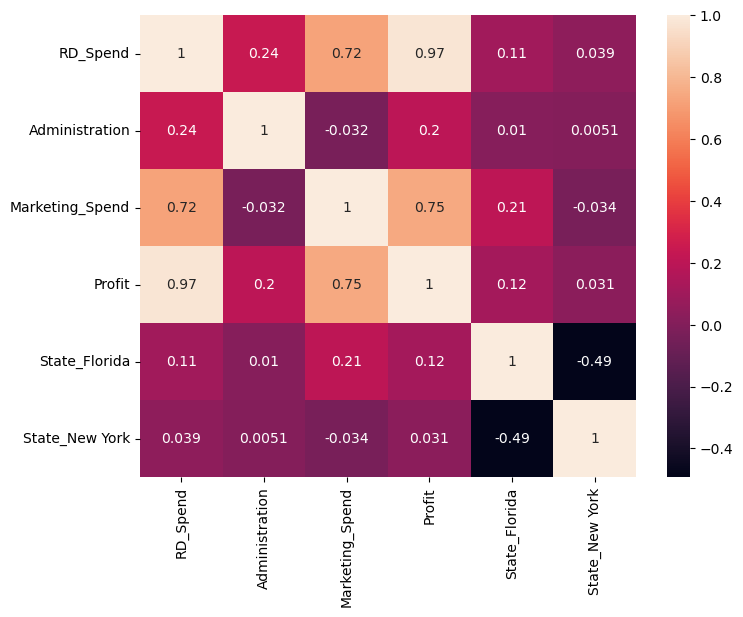

In [28]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True)

plt.show()

In [29]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coef_df.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
3,State_Florida,938.793006
4,State_New York,6.987760
0,RD_Spend,0.805630
2,Marketing_Spend,0.029855
1,Administration,-0.068788


In [30]:
print("Intercept =", model.intercept_)
print("Coefficients =", model.coef_)

Intercept = 54028.03959364584
Coefficients = [ 8.05630064e-01 -6.87878823e-02  2.98554429e-02  9.38793006e+02
  6.98775997e+00]


In [31]:
## Regression Analysis

In [33]:
print("""
Profit = 54028.04
+ (0.8056 * RD_Spend)
- (0.0688 * Administration)
+ (0.0299 * Marketing_Spend)
+ (938.79 * State_Florida)
+ (6.99 * State_New York)
""")


Profit = 54028.04
+ (0.8056 * RD_Spend)
- (0.0688 * Administration)
+ (0.0299 * Marketing_Spend)
+ (938.79 * State_Florida)
+ (6.99 * State_New York)



In [34]:
prediction_data = pd.DataFrame({
    'RD_Spend':[21892.92,23940.93],
    'Administration':[81910.77,96489.63],
    'Marketing_Spend':[164270.7,137001.1],
    'State_Florida':[0,0],
    'State_New York':[0,0]
})

predictions = model.predict(prediction_data)

print(predictions)

[70935.54023188 70768.48376694]


In [35]:
# Profit Prediction

In [36]:
prediction_data = pd.DataFrame({
    'RD_Spend':[21892.92,23940.93],
    'Administration':[81910.77,96489.63],
    'Marketing_Spend':[164270.7,137001.1],
    'State_Florida':[0,0],
    'State_New York':[0,0]
})

predictions = model.predict(prediction_data)

prediction_result = prediction_data.copy()
prediction_result['Predicted_Profit'] = predictions

prediction_result

,RD_Spend,Administration,Marketing_Spend,State_Florida,State_New York,Predicted_Profit
0,21892.92,81910.77,164270.7,0,0,70935.540232
1,23940.93,96489.63,137001.1,0,0,70768.483767


In [44]:
# Note

#The problem statement does not specify the State for the prediction records. Therefore, predictions were generated using the reference state created during dummy variable encoding.